# Formação Vibe Coding: Do Excel ao Python 📊

Este notebook é o seu guia definitivo para transitar do Excel para o Python. Ele foi desenhado para garantir que qualquer pessoa da equipa obtenha resultados 100% idênticos ao Excel original.

## 🧪 Regras de Ouro (Blindagem)
Sempre que pedir código à IA, use estas dicas técnicas:
1. **Mapeamento por Índice**: Peça para usar `iloc` (ex: `df.iloc[:, 5]`) em vez de nomes de colunas, pois os cabeçalhos do Excel podem ser complexos.
2. **Tratamento de Tipos**: Use sempre `pd.to_numeric(..., errors='coerce')` para evitar erros com textos em colunas de números.
3. **Formatação Explícita**: Use as funções `format_euro` e `format_pct` criadas abaixo para garantir que a saída visual seja exatamente como no Excel.

### Célula 1: Configuração e Carregamento Robusto

**Excel**: Abrir o ficheiro e verificar os dados.

**Prompt sugerido para a IA (BLINDAGEM)**:
> "Lê a folha 'Mapa diário' do ficheiro 'Cópia de Mapa diário.xlsx' ignorando as primeiras 6 linhas. 
> - Usa `iloc` para mapear: Col 0 (Dia), Col 1 (Weekday). 
> - Faturamento: Índice 5 (2025), 6 (2026), 7 (Orc). 
> - Margem: Índice 16 (2025), 17 (2026), 19 (Orc).
> - Converte tudo para numérico (`pd.to_numeric`).
> - Aplica as funções `format_euro` e `format_pct` na visualização final."

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# FUNÇÕES DE FORMATAÇÃO PARA IGUALAR AO EXCEL
def format_euro(x):
    try:
        if pd.isna(x) or not isinstance(x, (int, float, np.number)): return ""
        # Formato: 1.234,56 €
        return f"{x:,.2f} €".replace(',', 'X').replace('.', ',').replace('X', '.')
    except: return str(x)

def format_pct(x):
    try:
        if pd.isna(x) or not isinstance(x, (int, float, np.number)): return ""
        return f"{x*100:.2f}%"
    except: return str(x)

# CARREGAMENTO COM BLINDAGEM (ÍNDICES FIXOS)
df_raw = pd.read_excel('Cópia de Mapa diário.xlsx', sheet_name='Mapa diário', skiprows=6)

df = pd.DataFrame({
    'Dia': df_raw.iloc[:, 0],
    'Weekday': df_raw.iloc[:, 1],
    'Fact_2025': pd.to_numeric(df_raw.iloc[:, 5], errors='coerce'),
    'Fact_2026': pd.to_numeric(df_raw.iloc[:, 6], errors='coerce'),
    'Fact_Orc_26': pd.to_numeric(df_raw.iloc[:, 7], errors='coerce'),
    'Marg_2025': pd.to_numeric(df_raw.iloc[:, 16], errors='coerce') / pd.to_numeric(df_raw.iloc[:, 5], errors='coerce'),
    'Marg_2026': pd.to_numeric(df_raw.iloc[:, 17], errors='coerce') / pd.to_numeric(df_raw.iloc[:, 6], errors='coerce'),
    'Marg_Orc_26': pd.to_numeric(df_raw.iloc[:, 19], errors='coerce') / pd.to_numeric(df_raw.iloc[:, 7], errors='coerce')
})

# Limpeza de dados nulos no faturamento real
df = df.dropna(subset=['Fact_2025', 'Weekday'])
df = df[~df['Weekday'].astype(str).str.contains('TOTAL', na=False)]
df['Dia'] = df['Dia'].fillna('')

# Visualização da Tabela Consolidada
df_view = df.head(10).copy()
cols_moeda = ['Fact_2025', 'Fact_2026', 'Fact_Orc_26']
cols_pct = ['Marg_2025', 'Marg_2026']

for c in cols_moeda: df_view[c] = df_view[c].apply(format_euro)
for c in cols_pct: df_view[c] = df_view[c].apply(format_pct)

print("Resultados Consolidados (Conforme Excel):")
df_view[['Dia', 'Weekday', 'Fact_2025', 'Marg_2025', 'Fact_2026', 'Marg_2026']]

Resultados Consolidados (Conforme Excel):


,Dia,Weekday,Fact_2025,Marg_2025,Fact_2026,Marg_2026
0,,Sabado,"476.799,55 €",47.88%,,
1,1.0,Domingo,"421.146,20 €",47.28%,"511.594,57 €",49.00%
2,2.0,Segunda,"330.463,30 €",49.69%,"224.533,86 €",52.21%
3,3.0,Terça,"355.850,44 €",49.63%,"220.804,87 €",51.77%
4,4.0,Quarta,"230.737,60 €",50.08%,"248.515,85 €",51.68%
5,5.0,Quinta,"213.592,97 €",50.04%,"232.248,54 €",51.93%
6,6.0,Sexta,"259.634,52 €",49.71%,"293.325,95 €",51.73%
7,7.0,Sabado,"519.083,15 €",46.93%,"540.481,68 €",47.09%
8,8.0,Domingo,"425.658,60 €",49.55%,"497.899,14 €",48.19%
9,9.0,Segunda,"195.181,33 €",50.32%,"205.952,78 €",52.17%


### Célula 2: Totais Gerais e Variações

**Excel**: Somatórios nas linhas inferiores.

**Prompt sugerido para a IA (BLINDAGEM)**:
> "Calcula o total somado (`sum`) de Fact_2025 e Fact_2026. Calcula a média (`mean`) das Margens. 
> - Apresenta um resumo no console.
> - Usa as funções de formatação `format_euro` para dinheiro e `format_pct` para margens."

In [7]:
tot_fact_25 = df['Fact_2025'].sum()
tot_fact_26 = df['Fact_2026'].sum()
med_marg_25 = df['Marg_2025'].mean()
med_marg_26 = df['Marg_2026'].mean()

print("=== RESUMO EXECUTIVO (VALORES TOTAIS) ===")
print(f"Faturamento Total 2025: {format_euro(tot_fact_25)}")
print(f"Faturamento Total 2026: {format_euro(tot_fact_26)}")
print(f"Margem Média 2025:       {format_pct(med_marg_25)}")
print(f"Margem Média 2026:       {format_pct(med_marg_26)}")

=== RESUMO EXECUTIVO (VALORES TOTAIS) ===
Faturamento Total 2025: 9.780.216,39 €
Faturamento Total 2026: 6.946.576,92 €
Margem Média 2025:       49.43%
Margem Média 2026:       50.14%


### Célula 3: Gráfico de Tendência (Faturamento)

**Excel**: Gráfico de Linhas.

**Prompt sugerido para a IA (BLINDAGEM)**:
> "Cria um gráfico de linhas para Fact_2025 e Fact_2026. 
> - **Dica de Blindagem**: Para os eixos (`xticks`), usa `df['Dia'].astype(str).tolist()` para garantir que o Matplotlib não confunda números com posições."

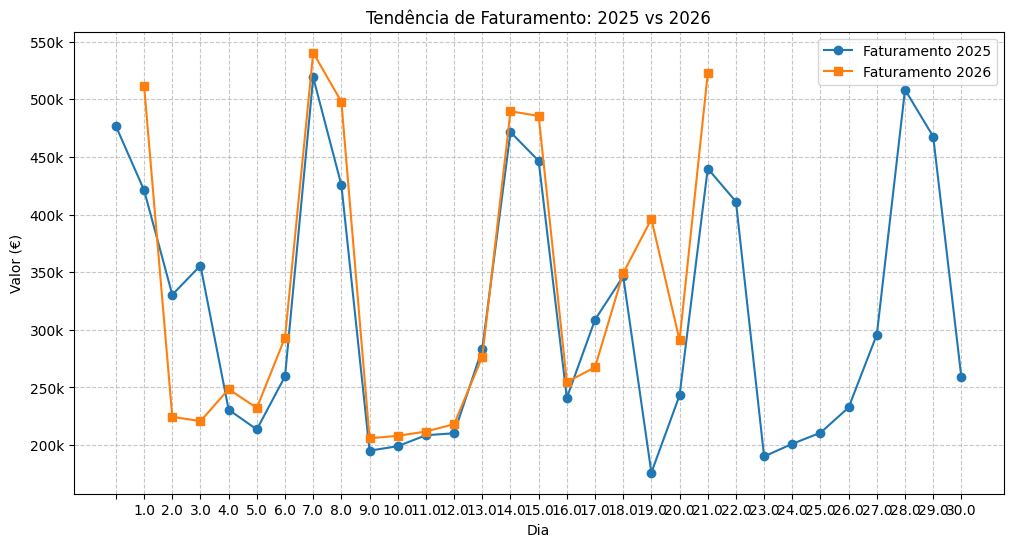

In [8]:
plt.figure(figsize=(12, 6))

# Garantia de strings no eixo X para evitar erros
eixo_x = df['Dia'].astype(str).tolist()

plt.plot(eixo_x, df['Fact_2025'], label='Faturamento 2025', marker='o', color='#1f77b4')
plt.plot(eixo_x, df['Fact_2026'], label='Faturamento 2026', marker='s', color='#ff7f0e')

plt.title('Tendência de Faturamento: 2025 vs 2026')
plt.xlabel('Dia')
plt.ylabel('Valor (€)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e3:.0f}k'))

plt.show()

### Célula 4: Análise de Margem (Gráfico de Barras)

**Excel**: Verificação de rentabilidade.

**Prompt sugerido para a IA (BLINDAGEM)**:
> "Cria um gráfico de barras lado a lado comparando a Marg_2025 (verde) e Marg_2026 (vermelho) por dia. 
> - O eixo Y deve estar em formato de percentagem.
> - **Dica para a IA não falhar**: Atenção que a coluna 'Dia' tem valores vazios. Força o eixo dos dias (X) a ser texto (string) e agrupa as barras usando posições numéricas, para que o gráfico não fique desconfigurado ou dê erro."

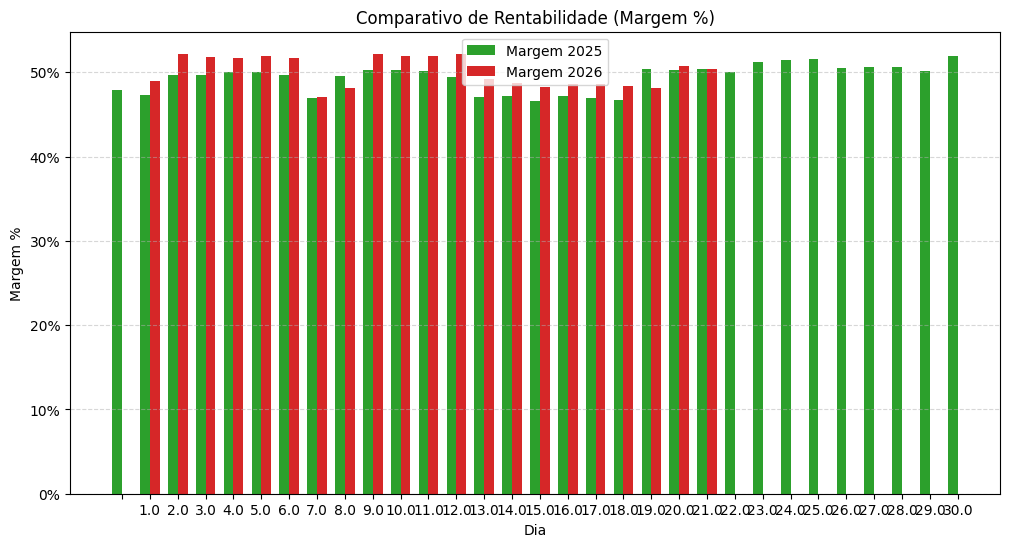

In [9]:
plt.figure(figsize=(12, 6))

width = 0.35
indices = np.arange(len(df))

plt.bar(indices - width/2, df['Marg_2025'], width, label='Margem 2025', color='#2ca02c')
plt.bar(indices + width/2, df['Marg_2026'], width, label='Margem 2026', color='#d62728')

plt.title('Comparativo de Rentabilidade (Margem %)')
plt.xlabel('Dia')
plt.ylabel('Margem %')
plt.xticks(indices, df['Dia'].astype(str).tolist())
plt.legend()
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()